This project tested a wide range of architectures and algorithm settings to prevent overfitting and maximize the models' generalization capabilities.

Here is a summary of the main parameter spaces tested (including using GridSearchCV):

Neural Networks (MLPClassifier):
* **Architectures:** Shallow `(10,)`, `(128,)`, Deep `(32, 16)`, `(64, 32, 16)`.
* **Activation Functions:** `relu`, `tanh`, `logistic`.
* **Regularization (alpha):** From `0.0001` (weak) to `0.05` (strong).
* **Optimizers:** `adam`, `sgd`, `lbfgs`.
* Additionally, the `early_stopping` mechanisms were tested.

Logistic Regression / Perceptron:
* **Penalties:** `l1` (Lasso), `l2` (Ridge), `None`.
* **C-Ratio / eta0:** Testing for extreme values ​​to control the margin.
* **Class Balancing:** Use `class_weight='balanced'` in response to imbalance in the target variable.

## Loading data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/hotel_bookings.csv')
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [ ]:
data.drop(columns=["reservation_status_date"], axis=1, inplace=True)
data.drop(columns=["reservation_status"], axis=1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
data.is_canceled.value_counts(normalize=True)

,proportion
is_canceled,
0,0.629584
1,0.370416


## Missing data

In [ ]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)
missing_data[:5]

,missing value,percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
lead_time,0,0.000000


In [ ]:
data = data.drop(columns=['company'])

In [ ]:
data['children'] = data['children'].fillna(data['children'].mode()[0])
data['country'] = data['country'].fillna(data['country'].mode()[0])
data['agent'] = data['agent'].fillna(0)
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,No Deposit,0.0,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,No Deposit,0.0,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,No Deposit,0.0,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1


In [ ]:
sorted(data['reserved_room_type'].unique())

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'L', 'P']

In [ ]:
meal_map = {'Undefined': 0, 'SC': 0, 'BB': 1, 'HB': 2, 'FB': 3}
data['meal'] = data['meal'].map(meal_map)
room_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'L': 9, 'P': 10}
data['assigned_room_type'] = data['assigned_room_type'].map(room_map)
data['reserved_room_type'] = data['reserved_room_type'].map(room_map)


In [ ]:
data['country'].unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', 'ROU', 'NOR', 'OMN',
       'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA', 'NLD',
       'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN', 'MOZ',
       'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR', 'UKR',
       'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU', 'TUR',
       'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA', 'KOR',
       'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN', 'GEO',
       'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY', 'KWT',
       'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN', 'LBN',
       'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM', 'MKD',
       'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS', 'COM',
       'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI', 'SAU',
       'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU', 'MDG',
       'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI', 'STP',
       'KNA', 'ETH', 

In [ ]:
data['country'].value_counts()

,count
country,
PRT,49078
GBR,12129
FRA,10415
ESP,8568
DEU,7287
...,...
MRT,1
KIR,1
SDN,1


In [ ]:
top_10_countries = data['country'].value_counts().nlargest(10).index

data['country'] = data['country'].apply(lambda x: x if x in top_10_countries else 'Other')

In [ ]:
data['has_agent'] = np.where(data['agent'] == 0, 0, 1)
data = data.drop(columns=['agent'])

In [ ]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)
missing_data[:5]

,missing value,percentage
assigned_room_type,642,0.537733
is_canceled,0,0.000000
lead_time,0,0.000000
arrival_date_year,0,0.000000
hotel,0,0.000000


In [ ]:
data['assigned_room_type'] = data['assigned_room_type'].fillna(data['assigned_room_type'].mode()[0])

In [ ]:
c = ['arrival_date_month','hotel', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type', 'country']
data = pd.get_dummies(data, columns=c, drop_first=True, dtype=int)

In [ ]:
data.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,country_BRA,country_DEU,country_ESP,country_FRA,country_GBR,country_IRL,country_ITA,country_NLD,country_Other,country_PRT
0,0,342,2015,27,1,0,0,2,0.0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,737,2015,27,1,0,0,2,0.0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,7,2015,27,1,0,1,1,0.0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,13,2015,27,1,0,1,1,0.0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,0,0,1,0,0,0,0,0


## Outliers

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119390.0,0.103886,0.398555,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


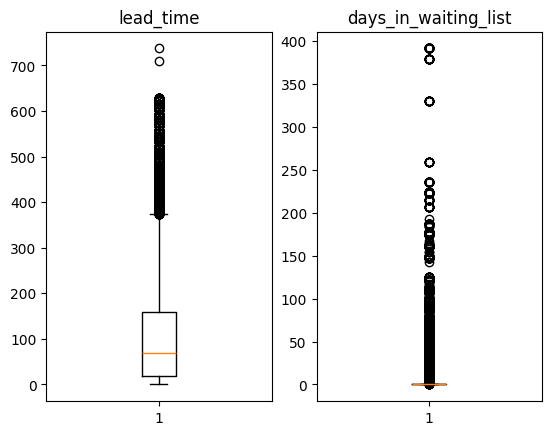

In [ ]:
plt.subplot(1, 2, 1)
plt.boxplot(x=data['lead_time'])
plt.title('lead_time')
plt.subplot(1, 2, 2)
plt.boxplot(x=data['days_in_waiting_list'])
plt.title('days_in_waiting_list')
plt.show()

In [ ]:
q1 = np.quantile(data['lead_time'], 0.25)
q3 = np.quantile(data['lead_time'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['lead_time'] > 1 * upper_lim) | (data['lead_time'] < 1 * lower_lim)]
outliers

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,country_BRA,country_DEU,country_ESP,country_FRA,country_GBR,country_IRL,country_ITA,country_NLD,country_Other,country_PRT
1,0,737,2015,27,1,0,0,2,0.0,0,...,0,0,0,0,0,0,0,0,0,1
225,0,394,2015,28,8,2,5,2,0.0,0,...,0,0,0,0,1,0,0,0,0,0
890,0,460,2015,32,3,2,5,1,0.0,0,...,0,0,0,0,1,0,0,0,0,0
1516,0,381,2015,36,1,4,10,2,0.0,0,...,0,0,0,0,1,0,0,0,0,0
1672,0,382,2015,37,8,4,10,2,0.0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119102,0,518,2017,34,26,2,1,1,0.0,0,...,0,0,0,0,0,0,0,0,0,1
119107,0,518,2017,34,26,2,1,2,0.0,0,...,0,0,0,0,0,0,0,0,1,0
119109,0,518,2017,34,26,2,1,2,0.0,0,...,0,0,0,0,1,0,0,0,0,0
119111,0,518,2017,34,26,2,1,2,0.0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
q1 = np.quantile(data['days_in_waiting_list'], 0.25)
q3 = np.quantile(data['days_in_waiting_list'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['days_in_waiting_list'] > 10000 * upper_lim) | (data['days_in_waiting_list'] < 10000 * lower_lim)]
outliers['days_in_waiting_list'].unique()

array([ 50,  47,  65, 122,  75, 101, 150, 125,  14,  60,  34, 100,  22,
       121,  61,  39,   5,   1,   8, 107,  43,  52,   2,  11, 142, 116,
        13,  44,  97,  83,   4, 113,  18,  20, 185,  93, 109,   6,  37,
       105, 154,  64,  99,  38,  48,  33,  77,  21,  80,  59,  40,  58,
        89,  53,  49,  69,  87,  91,  57, 111,  79,  98,  85,  63,  15,
         3,  41, 224,  31,  56, 187, 176,  71,  55,  96, 236, 259, 207,
       215, 160, 120,  30,  32,  27,  62,  24, 108, 147, 379,  70,  35,
       178, 330, 223, 174, 162, 391,  68, 193,  10,  76,  16,  28,   9,
       165,  17,  25,  46,   7,  84, 175, 183,  23, 117,  12,  54,  26,
        73,  45,  19,  42,  72,  81,  92,  74, 167,  36])

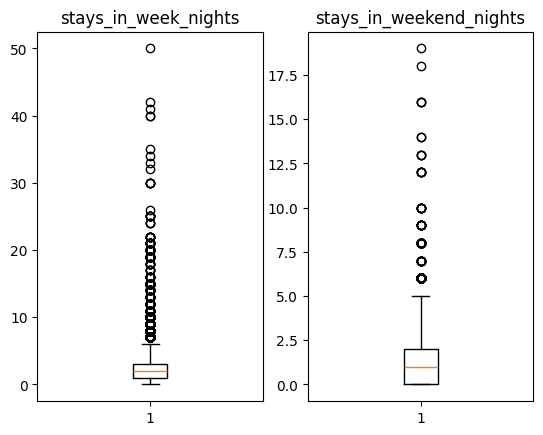

In [ ]:
plt.subplot(1, 2, 1)
plt.boxplot(x=data['stays_in_week_nights'])
plt.title('stays_in_week_nights')
plt.subplot(1, 2, 2)
plt.boxplot(x=data['stays_in_weekend_nights'])
plt.title('stays_in_weekend_nights')
plt.show()

In [ ]:
q1 = np.quantile(data['stays_in_week_nights'], 0.25)
q3 = np.quantile(data['stays_in_week_nights'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['stays_in_week_nights'] > 6 * upper_lim) | (data['stays_in_week_nights'] < 6 * lower_lim)]
outliers

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,country_BRA,country_DEU,country_ESP,country_FRA,country_GBR,country_IRL,country_ITA,country_NLD,country_Other,country_PRT
9839,1,322,2017,2,10,16,40,2,0.0,0,...,0,0,0,0,0,0,0,0,0,1
14037,0,113,2015,31,1,18,42,1,0.0,0,...,0,0,0,0,0,0,0,0,0,1
14038,0,126,2016,28,5,19,50,1,0.0,0,...,0,0,0,0,0,0,0,0,0,1
33924,0,71,2017,2,10,16,40,2,0.0,0,...,0,0,0,0,1,0,0,0,0,0
101794,0,140,2016,39,22,16,41,0,0.0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
data = data[~((data['stays_in_week_nights'] > 6 * upper_lim) | (data['stays_in_week_nights'] < 6 * lower_lim))]

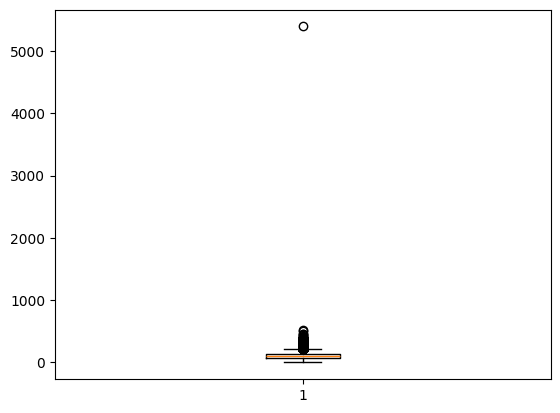

In [ ]:
plt.boxplot(x=data['adr'])
plt.show()

In [ ]:
q1 = np.quantile(data['adr'], 0.25)
q3 = np.quantile(data['adr'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['adr'] > 3 * upper_lim) | (data['adr'] < 3 * lower_lim)]
outliers

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,country_BRA,country_DEU,country_ESP,country_FRA,country_GBR,country_IRL,country_ITA,country_NLD,country_Other,country_PRT
48515,1,35,2016,13,25,0,1,2,0.0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
data = data[~((data['adr'] > 3 * upper_lim) | (data['adr'] < 3 * lower_lim))]

# Train Test

In [ ]:
X = data.drop(columns=['is_canceled'])
y = data['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Perceptron

In [ ]:
clf = Perceptron(
    max_iter=1000,
    eta0=0.1,
    random_state=42)

clf.fit(X_train,y_train)

train_accuracy = clf.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = clf.predict(X_test)
test_accuracy = clf.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.766070744782692
Accuracy on test set: 0.765077060531606


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.73      0.98      0.84     22549
           1       0.94      0.39      0.55     13267

    accuracy                           0.77     35816
   macro avg       0.83      0.69      0.70     35816
weighted avg       0.81      0.77      0.73     35816



In [ ]:
clf= Perceptron(
    penalty='l2',
    alpha=0.0001,
    eta0=0.01,
    max_iter=1000,
    random_state=42
)
clf.fit(X_train,y_train)

train_accuracy = clf.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = clf.predict(X_test)
test_accuracy = clf.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.7867844150871147
Accuracy on test set: 0.7856823765914674


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.79      0.90      0.84     22549
           1       0.78      0.59      0.67     13267

    accuracy                           0.79     35816
   macro avg       0.78      0.74      0.76     35816
weighted avg       0.78      0.79      0.78     35816



In [ ]:
clf= Perceptron(
    class_weight='balanced',
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    eta0=0.1,
    max_iter=1000,
    random_state=42
)
clf.fit(X_train,y_train)

train_accuracy = clf.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = clf.predict(X_test)
test_accuracy = clf.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.7528719126938541
Accuracy on test set: 0.7562821085548358


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.87      0.72      0.79     22549
           1       0.63      0.81      0.71     13267

    accuracy                           0.76     35816
   macro avg       0.75      0.77      0.75     35816
weighted avg       0.78      0.76      0.76     35816



In [ ]:
clf= Perceptron(
    class_weight='balanced',
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    eta0=0.1,
    max_iter=1000,
    random_state=42
)
clf.fit(X_train,y_train)

train_accuracy = clf.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = clf.predict(X_test)
test_accuracy = clf.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.7528719126938541
Accuracy on test set: 0.7562821085548358


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.87      0.72      0.79     22549
           1       0.63      0.81      0.71     13267

    accuracy                           0.76     35816
   macro avg       0.75      0.77      0.75     35816
weighted avg       0.78      0.76      0.76     35816



In [ ]:
clf = Perceptron(
    penalty = 'elasticnet',
    alpha=0.0001,
    l1_ratio=0.75,
    shuffle = False,
    random_state=42,
    early_stopping = True,
    validation_fraction=0.5,
    n_iter_no_change=4,
    class_weight = 'balanced'
)
clf.fit(X_train,y_train)

train_accuracy = clf.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = clf.predict(X_test)
test_accuracy = clf.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.7812200842427723
Accuracy on test set: 0.7811592584319857


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.75      0.98      0.85     22549
           1       0.92      0.45      0.60     13267

    accuracy                           0.78     35816
   macro avg       0.84      0.71      0.73     35816
weighted avg       0.81      0.78      0.76     35816



In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
pipeline_clf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', Perceptron(random_state=42, penalty='elasticnet'))
])

param_grid_clf = {
    'clf__alpha': [0.0001, 0.001],
    'clf__l1_ratio': [0.25,0.5, 0.75],
    'clf__class_weight': ['balanced', None],
    'clf__early_stopping': [True, False],
    'clf__shuffle': [True, False]
}

grid_clf = GridSearchCV(pipeline_clf, param_grid_clf, cv=5, scoring='f1', n_jobs=-1)
grid_clf.fit(X_train_raw, y_train_raw)

print("Best parameters for single perceptron:", grid_clf.best_params_)

Best parameters for single perceptron: {'clf__alpha': 0.0001, 'clf__class_weight': 'balanced', 'clf__early_stopping': True, 'clf__l1_ratio': 0.75, 'clf__shuffle': True}


In [ ]:
clf = Perceptron(
    random_state=42,
    penalty = 'elasticnet',
    alpha=0.0001,
    class_weight = 'balanced',
    l1_ratio=0.75,
    shuffle = True,
    early_stopping = True,
)
clf.fit(X_train,y_train)

train_accuracy = clf.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = clf.predict(X_test)
test_accuracy = clf.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.7756796860042121
Accuracy on test set: 0.7780600848782667


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.83      0.81      0.82     22549
           1       0.69      0.72      0.71     13267

    accuracy                           0.78     35816
   macro avg       0.76      0.77      0.76     35816
weighted avg       0.78      0.78      0.78     35816



# Sigmoid function

In [ ]:
clf = LogisticRegression(
    max_iter=2000,
    solver='lbfgs'
)

clf.fit(X_train,y_train)

train_accuracy = clf.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = clf.predict(X_test)
test_accuracy = clf.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8071630289105878
Accuracy on test set: 0.8070415456779093


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.81      0.91      0.86     22549
           1       0.80      0.64      0.71     13267

    accuracy                           0.81     35816
   macro avg       0.81      0.77      0.78     35816
weighted avg       0.81      0.81      0.80     35816



In [ ]:
clf = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.1,
    max_iter=2000,
    random_state=42
)
clf.fit(X_train,y_train)

train_accuracy = clf.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = clf.predict(X_test)
test_accuracy = clf.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.808000670112962
Accuracy on test set: 0.8074882733973643


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.81      0.91      0.86     22549
           1       0.80      0.64      0.71     13267

    accuracy                           0.81     35816
   macro avg       0.81      0.77      0.78     35816
weighted avg       0.81      0.81      0.80     35816



In [ ]:
clf = LogisticRegression(
    penalty='l2',
    solver='saga',
    C=10,
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)
clf.fit(X_train,y_train)

train_accuracy = clf.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = clf.predict(X_test)
test_accuracy = clf.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8077374114493586
Accuracy on test set: 0.8038027697118606


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.86      0.82      0.84     22549
           1       0.72      0.78      0.75     13267

    accuracy                           0.80     35816
   macro avg       0.79      0.80      0.79     35816
weighted avg       0.81      0.80      0.81     35816



# MLP

In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
pipeline_mlp = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPClassifier(max_iter=1000, random_state=42))
])

param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(10,), (32, 16)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001]
}

grid_mlp = GridSearchCV(pipeline_mlp, param_grid_mlp, cv=3, scoring='f1', n_jobs=-1)
grid_mlp.fit(X_train_raw, y_train_raw)

print("Best parameters for MLP:", grid_mlp.best_params_)

Best parameters for MLP: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (32, 16)}


In [ ]:
mlp = MLPClassifier(max_iter=1000, random_state=42, hidden_layer_sizes=(32,16),
                    activation='tanh', alpha=0.0001)
mlp.fit(X_train,y_train)

train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8842020869232242
Accuracy on test set: 0.8656466383739111


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.88      0.92      0.90     22549
           1       0.85      0.78      0.81     13267

    accuracy                           0.87     35816
   macro avg       0.86      0.85      0.85     35816
weighted avg       0.86      0.87      0.86     35816



## (64, 32, 16)

In [ ]:
mlp = MLPClassifier(max_iter=1000, random_state=42, hidden_layer_sizes=(64, 32, 16),
                    activation='tanh', alpha=0.0001)
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.9166307677579935
Accuracy on test set: 0.8574659370113915


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.88      0.89      0.89     22549
           1       0.81      0.80      0.81     13267

    accuracy                           0.86     35816
   macro avg       0.85      0.85      0.85     35816
weighted avg       0.86      0.86      0.86     35816



In [ ]:
mlp = MLPClassifier(max_iter=1000, random_state=42, hidden_layer_sizes=(64, 32, 16),
                    activation='tanh', alpha=0.001)
mlp.fit(X_train, y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.910635650009573
Accuracy on test set: 0.8615144069689524


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.88      0.90      0.89     22549
           1       0.82      0.80      0.81     13267

    accuracy                           0.86     35816
   macro avg       0.85      0.85      0.85     35816
weighted avg       0.86      0.86      0.86     35816



In [ ]:
mlp = MLPClassifier(max_iter=1000, random_state=42, hidden_layer_sizes=(64, 32, 16),
                    activation='tanh', alpha=0.001, solver='sgd')
mlp.fit(X_train, y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8620644265747655
Accuracy on test set: 0.8540875586330132


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.85      0.94      0.89     22549
           1       0.87      0.71      0.78     13267

    accuracy                           0.85     35816
   macro avg       0.86      0.82      0.84     35816
weighted avg       0.86      0.85      0.85     35816



## (128,)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param = {
    'hidden_layer_sizes': [(128,), (64, 32), (32, 16), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01, 0.1]
}

mlp = MLPClassifier(max_iter=2000, early_stopping=True, random_state=42)
search = RandomizedSearchCV(mlp, param, n_iter=30, cv=3, n_jobs=-1, random_state=42, verbose=2)
search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'hidden_layer_sizes': (128,), 'alpha': 0.0001, 'activation': 'relu'}


In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(128,), max_iter=2000, early_stopping=True,
                    random_state=42, alpha=0.0001, activation='relu')
mlp.fit(X_train, y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8645653838789967
Accuracy on test set: 0.8560140719231628


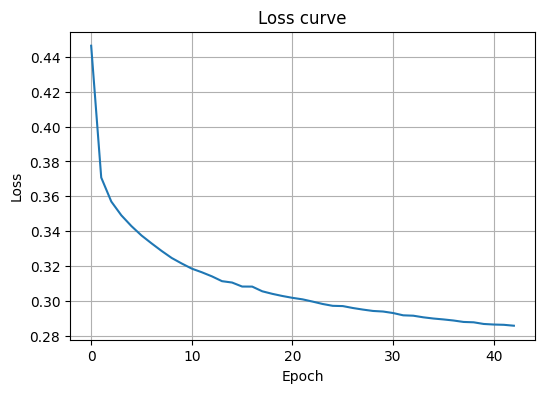

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(mlp.loss_curve_)
plt.title("Loss curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.87      0.91      0.89     22549
           1       0.84      0.76      0.80     13267

    accuracy                           0.86     35816
   macro avg       0.85      0.84      0.84     35816
weighted avg       0.86      0.86      0.85     35816



In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(128,), max_iter=2000, early_stopping=True,
                    random_state=42, alpha=0.0001, activation='relu',
                    validation_fraction=0.2, n_iter_no_change=10)
mlp.fit(X_train, y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8662885314953092
Accuracy on test set: 0.8560978333705607


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.88      0.89      0.89     22549
           1       0.81      0.79      0.80     13267

    accuracy                           0.86     35816
   macro avg       0.85      0.84      0.84     35816
weighted avg       0.86      0.86      0.86     35816



## (128, 64)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=2000, early_stopping=True,
                    random_state=42, alpha=0.0001, activation='relu',
                    validation_fraction=0.2)
mlp.fit(X_train, y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.887014168102623
Accuracy on test set: 0.8635805226714318


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.87      0.91      0.89     22549
           1       0.84      0.78      0.81     13267

    accuracy                           0.86     35816
   macro avg       0.86      0.85      0.85     35816
weighted avg       0.86      0.86      0.86     35816



In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=2000, early_stopping=True,
                    random_state=42, alpha=0.001, activation='relu',
                    validation_fraction=0.3)
mlp.fit(X_train, y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8775368562129044
Accuracy on test set: 0.8600625418807237


## (32, 16, 8)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(32, 16, 8),max_iter=2000, early_stopping=True,
                    random_state=42, alpha=0.0001, activation='relu')
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8669227455485353
Accuracy on test set: 0.8574659370113915


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.86      0.92      0.89     22549
           1       0.85      0.74      0.79     13267

    accuracy                           0.86     35816
   macro avg       0.86      0.83      0.84     35816
weighted avg       0.86      0.86      0.86     35816



In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(32, 16, 8),max_iter=2000, early_stopping=True,
                    random_state=42, alpha=0.001, activation='relu')
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8694715680643308
Accuracy on test set: 0.8592249274067456


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.88      0.90      0.89     22549
           1       0.82      0.79      0.81     13267

    accuracy                           0.86     35816
   macro avg       0.85      0.85      0.85     35816
weighted avg       0.86      0.86      0.86     35816



In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(32, 16, 8),max_iter=2000, early_stopping=True,
                    random_state=42, alpha=0.01, activation='relu')
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8659056098027953
Accuracy on test set: 0.8553160598615144


In [ ]:
class_report = classification_report(y_test, pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.86      0.92      0.89     22549
           1       0.85      0.74      0.79     13267

    accuracy                           0.86     35816
   macro avg       0.85      0.83      0.84     35816
weighted avg       0.85      0.86      0.85     35816



# (32, 16)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(32, 16),max_iter=2000, early_stopping=True,
                    random_state=42, alpha=0.0001, activation='relu')
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8633328546812177
Accuracy on test set: 0.8535570694661604


In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(32, 16),max_iter=2000, early_stopping=True,
                    random_state=42, alpha=0.001, activation='tanh')
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8641585295807007
Accuracy on test set: 0.8556790261335716


In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(32, 16),max_iter=2000,
                    random_state=42, alpha=0.0001, activation='tanh')
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

Accuracy on train set: 0.8842020869232242
Accuracy on test set: 0.8656466383739111


In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(32, 16),max_iter=2000,
                    random_state=42, alpha=0.0001, activation='tanh')
scores = cross_validate(
    mlp, X_train, y_train, cv=5, return_train_score=True,
    scoring=("accuracy", "precision", "recall", "f1")
)
scores

{'fit_time': array([159.86604619, 207.57473588, 205.25904799, 182.33236885,
        158.18553948]),
 'score_time': array([0.07434177, 0.07193446, 0.07525563, 0.07252431, 0.07780576]),
 'test_accuracy': array([0.861972  , 0.86167285, 0.86179251, 0.86567343, 0.86328008]),
 'train_accuracy': array([0.87887037, 0.8847339 , 0.88582583, 0.88002393, 0.88219281]),
 'test_precision': array([0.80786303, 0.83046516, 0.84278396, 0.86375369, 0.85329233]),
 'train_precision': array([0.83589971, 0.86551813, 0.87017589, 0.88942643, 0.87960798]),
 'test_recall': array([0.82313035, 0.78727185, 0.77063479, 0.75674366, 0.76191245]),
 'train_recall': array([0.83738491, 0.81553869, 0.81307543, 0.77208852, 0.79009853]),
 'test_f1': array([0.81542523, 0.80829187, 0.80509619, 0.80671545, 0.80501749]),
 'train_f1': array([0.83664165, 0.83978544, 0.84065716, 0.82661421, 0.83245405])}

## (30,10)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(30,10),max_iter=2000,
                    random_state=42, alpha=0.0001, activation='relu')
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(mlp.loss_curve_)
plt.title("Loss curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(30,10),max_iter=2000,
                    random_state=42, alpha=0.001, activation='relu')
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(30,10),max_iter=2000,
                    random_state=42, alpha=0.001, activation='relu', learning_rate_init=0.1)
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(30,10),max_iter=2000, random_state=42,
                    alpha=0.001, activation='relu',early_stopping = True)
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(30,10),max_iter=2000, random_state=42,
                    alpha=0.001, activation='relu',early_stopping = True, validation_fraction=0.2)
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(30,10),max_iter=2000, random_state=42,
                    alpha=0.001, activation='relu', early_stopping = True, solver='sgd')
mlp.fit(X_train,y_train)
train_accuracy = mlp.score(X_train,y_train)
print("Accuracy on train set:", train_accuracy)
pred = mlp.predict(X_test)
test_accuracy = mlp.score(X_test, y_test)
print("Accuracy on test set:", test_accuracy)

### MLPClassifier model results

|hidden_layer_sizes | activation | alpha | solver | early_stopping | validation_fraction | Accuracy Train | Accuracy Test |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
|(32,16) | tanh | 0.0001 | adam | False | – | 89% | 87% |
|(32,16) | tanh | 0.001 | adam | True | – | 86% | 86% |
|(64,32,16) | tanh | 0.0001 | adam | False | – | 91% | 86% |
|(64,32,16) | tanh | 0.001 | adam | False | – | 91% | 86% |
|(64,32,16) | tanh | 0.001 | sgd | False | – | 86% | 85% |
|(128,) | relu | 0.0001 | adam | True | 0.1 | 86% | 86% |
|(128,) | relu | 0.0001 | adam | True | 0.2 | 87% | 86% |
|(128,64) | relu | 0.0001 | adam | True | 0.2 | 89% | 86% |
|(128,64) | relu | 0.001 | adam | True | 0.3 | 88% | 86% |
|(32,16,8) | relu | 0.0001 | adam | True | 0.1 | 87% | 86% |
|(32,16,8) | relu | 0.001 | adam | True | 0.1 | 87% | 86% |
|(32,16,8) | relu | 0.01 | adam | True | 0.1 | 87% | 85% |
|(30,10) | relu | 0.0001 | adam | False | – | 87% | 86% |
|(30,10) | relu | 0.001 | adam | True | 0.1 | 86% | 86% |
|(30,10) | relu | 0.001 | sgd | True | 0.1 | 83% | 83% |